# SETUP & IMPORTS

In [48]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, pointbiserialr
import warnings

warnings.filterwarnings("ignore")

# Aesthetics
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.facecolor"] = "white"
PALETTE = {"No": "#4C72B0", "Yes": "#DD8452"}
sns.set_style("whitegrid")

# Customer Churn Analysis - Week 1 EDA
**Author**: [Syed Najeebullah Shah]
**Date**: [4/3/2026]
**Course**: Introduction to Applied AI
## Project Overview
This notebook performs exploratory data analysis on customer churn data to identify
patterns and inform our predictive modeling approach.
## Table of Contents
1. Dataset Overview
2. Numerical Features Analysis
3. Categorical Features Analysis
4. Feature Correlations
5. Key Insights and Findings


# LOAD & FIRST LOOK

In [49]:
train = pd.read_csv("/kaggle/input/competitions/playground-series-s6e3/train.csv")
test  = pd.read_csv("/kaggle/input/competitions/playground-series-s6e3/test.csv")

print(f"\nTrain shape : {train.shape}")
print(f"Test shape  : {test.shape}")


Train shape : (594194, 21)
Test shape  : (254655, 20)


In [50]:
display(train.head())

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [51]:
print(train.dtypes)

id                    int64
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


In [52]:
display(train.describe())

,id,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000
mean,297096.500000,0.114102,36.577258,65.866223,2494.377057
std,171529.177262,0.317936,25.061922,31.067444,2353.916710
min,0.000000,0.000000,1.000000,18.250000,18.800000
25%,148548.250000,0.000000,12.000000,29.900000,639.650000
50%,297096.500000,0.000000,35.000000,74.100000,1433.650000
75%,445644.750000,0.000000,62.000000,90.800000,4263.800000
max,594193.000000,1.000000,72.000000,118.750000,8684.800000


In [53]:
display(train.describe(include="object"))

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194
unique,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,Female,Yes,No,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,No
freq,298738,309554,414362,557893,283384,272386,289474,250083,247377,288571,240301,241435,298918,365579,215372,460377


In [54]:
train["Churn"] = train["Churn"].map({"Yes": 1, "No": 0})

# MISSING VALUES & DUPLICATES

In [55]:
# --- a. Missing value heatmap ---

missing = train.isnull().sum()
missing_pct = (missing / len(train) * 100).round(2)
missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
missing_df = missing_df[missing_df["Missing Count"] > 0].sort_values("Missing %", ascending=False)

if missing_df.empty:
    print("✅ No missing values in train set!")
else:
    print(missing_df)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(missing_df.index, missing_df["Missing %"], color="#DD8452")
    ax.set_xlabel("Missing %")
    ax.set_title("Missing Values by Column")
    plt.tight_layout()
    plt.show()

✅ No missing values in train set!


In [56]:
# --- b. Duplicates ---

dups = train.duplicated().sum()
print(f"\n🔁 Duplicate rows: {dups}")


🔁 Duplicate rows: 0


# TARGET VARIABLE ANALYSIS

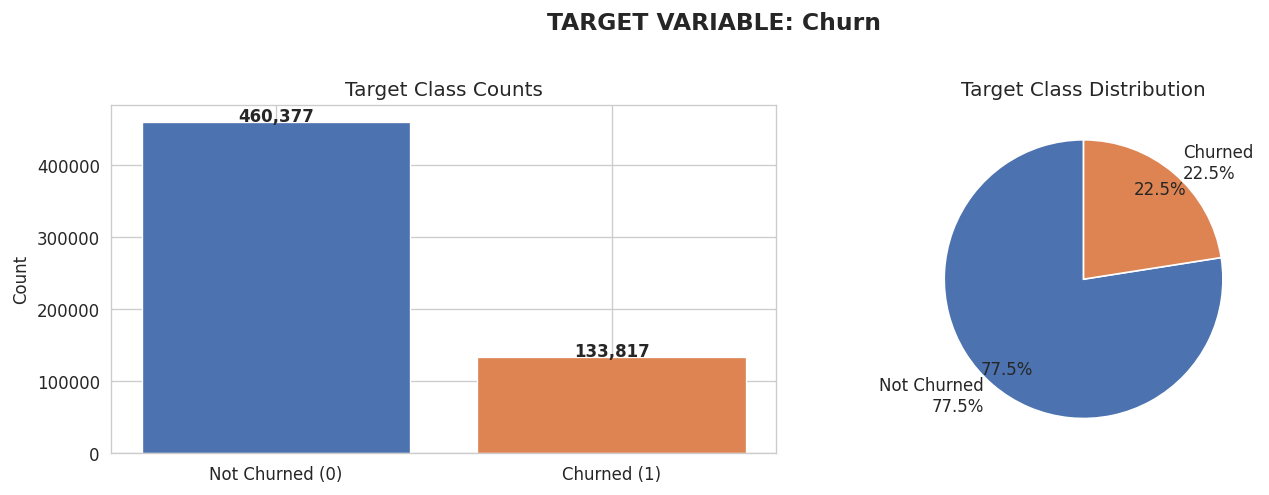


🎯 Class imbalance ratio: 77.5% vs 22.5%


In [57]:
churn_counts = train["Churn"].value_counts()
churn_pct    = train["Churn"].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
axes[0].bar(["Not Churned (0)", "Churned (1)"], churn_counts.values,
            color=["#4C72B0", "#DD8452"], edgecolor="white", linewidth=0.8)
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 500, f"{v:,}", ha="center", fontweight="bold")
axes[0].set_title("Target Class Counts")
axes[0].set_ylabel("Count")

# Pie chart
axes[1].pie(churn_pct.values, labels=[f"Not Churned\n{churn_pct.iloc[0]:.1f}%",
                                       f"Churned\n{churn_pct.iloc[1]:.1f}%"],
            colors=["#4C72B0", "#DD8452"], autopct="%1.1f%%",
            startangle=90, pctdistance=0.85)
axes[1].set_title("Target Class Distribution")

plt.suptitle("TARGET VARIABLE: Churn", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"\n🎯 Class imbalance ratio: {churn_pct.iloc[0]:.1f}% vs {churn_pct.iloc[1]:.1f}%")
if churn_pct.min() < 20:
    print("⚠️  Significant class imbalance detected — consider SMOTE, class_weight, or stratified folds.")

# CATEGORICAL FEATURE EDA

In [58]:
cat_cols = train.select_dtypes(include="object").columns.tolist()
cat_cols = [c for c in cat_cols if c not in ["id"]]

print(f"\n📂 Categorical columns: {cat_cols}")


📂 Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [59]:
# --- a. Value counts for each categorical column ---
for col in cat_cols:
    print(f"\n  {col}: {train[col].nunique()} unique values")
    print(train[col].value_counts().to_string())


  gender: 2 unique values
gender
Female    298738
Male      295456

  Partner: 2 unique values
Partner
Yes    309554
No     284640

  Dependents: 2 unique values
Dependents
No     414362
Yes    179832

  PhoneService: 2 unique values
PhoneService
Yes    557893
No      36301

  MultipleLines: 3 unique values
MultipleLines
No                  283384
Yes                 274509
No phone service     36301

  InternetService: 3 unique values
InternetService
Fiber optic    272386
DSL            181081
No             140727

  OnlineSecurity: 3 unique values
OnlineSecurity
No                     289474
Yes                    163993
No internet service    140727

  OnlineBackup: 3 unique values
OnlineBackup
No                     250083
Yes                    203384
No internet service    140727

  DeviceProtection: 3 unique values
DeviceProtection
No                     247377
Yes                    206090
No internet service    140727

  TechSupport: 3 unique values
TechSupport
No           

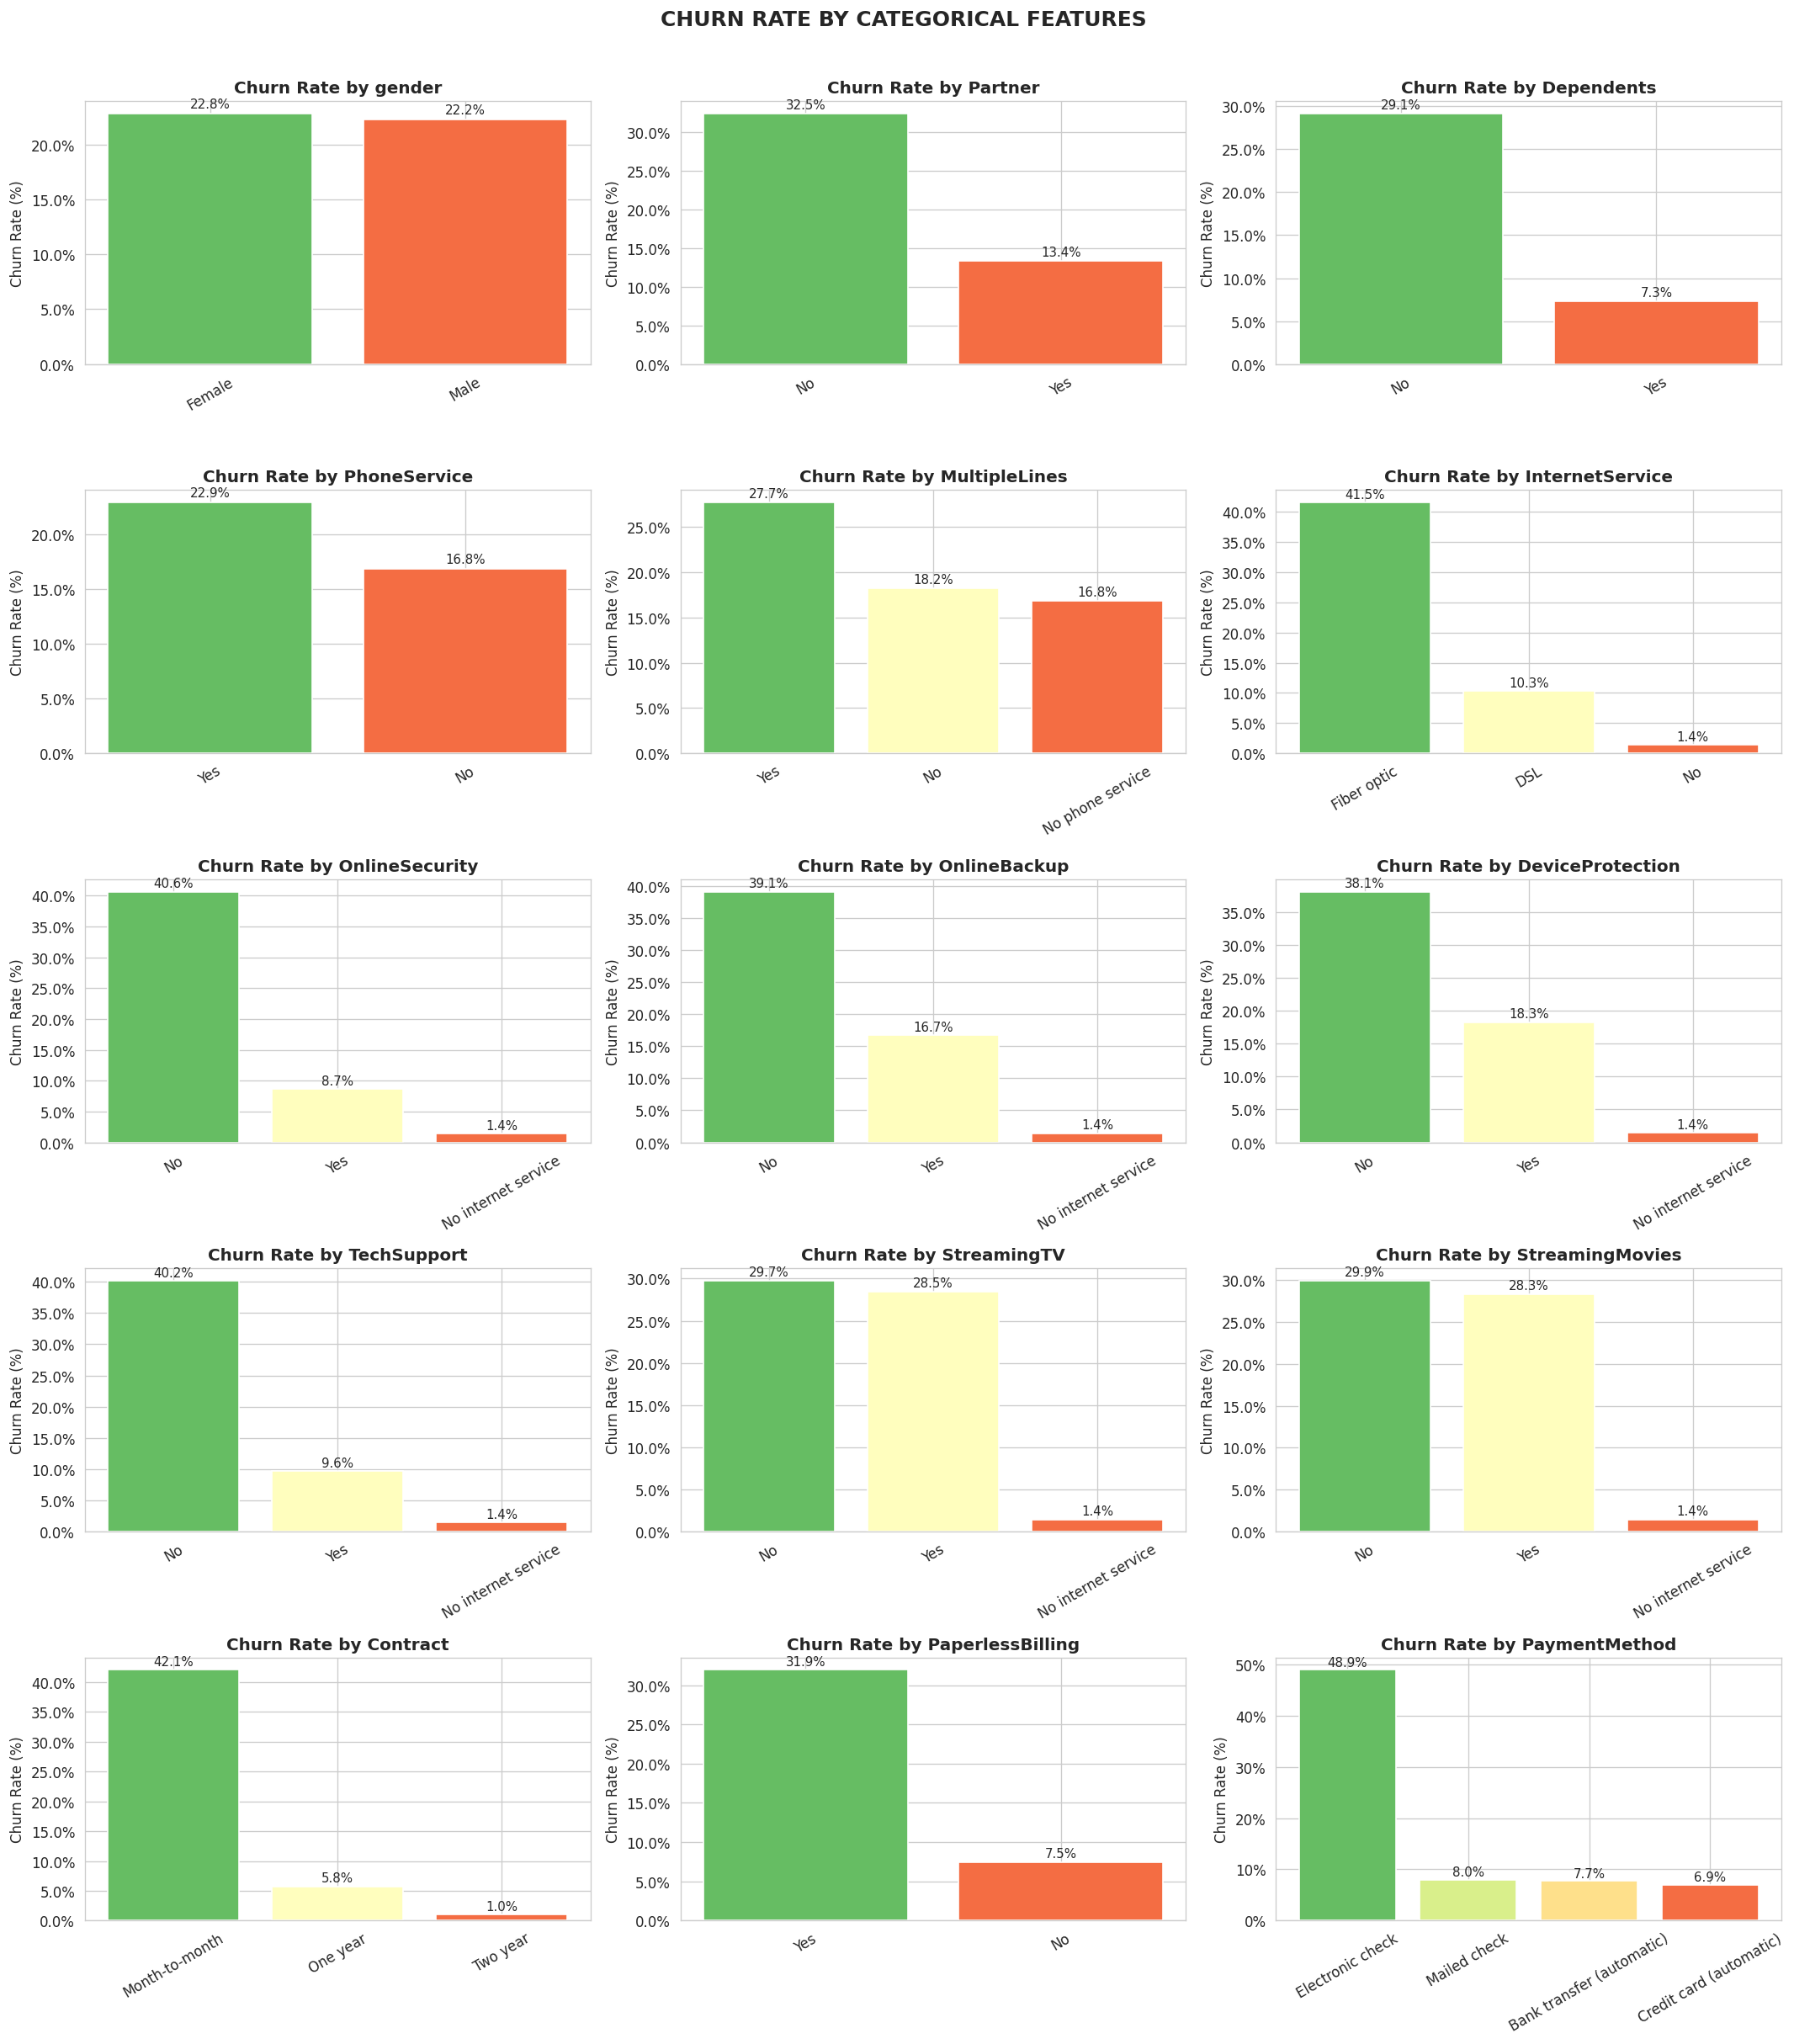

In [60]:
# --- b. Churn rate per category (the KEY plot for EDA) ---
n_cols = 3
n_rows = (len(cat_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = (train.groupby(col)["Churn"]
                       .mean()
                       .sort_values(ascending=False)
                       .mul(100))
    colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(churn_rate)))
    bars = axes[i].bar(churn_rate.index, churn_rate.values, color=colors, edgecolor="white")
    axes[i].set_title(f"Churn Rate by {col}", fontweight="bold")
    axes[i].set_ylabel("Churn Rate (%)")
    axes[i].tick_params(axis="x", rotation=30)
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter())
    for bar, val in zip(bars, churn_rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                     f"{val:.1f}%", ha="center", va="bottom", fontsize=9)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("CHURN RATE BY CATEGORICAL FEATURES", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


# NUMERIC FEATURE EDA

In [61]:
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ["id", "Churn", "SeniorCitizen"]]

print(f"\n🔢 Numeric columns: {num_cols}")


🔢 Numeric columns: ['tenure', 'MonthlyCharges', 'TotalCharges']


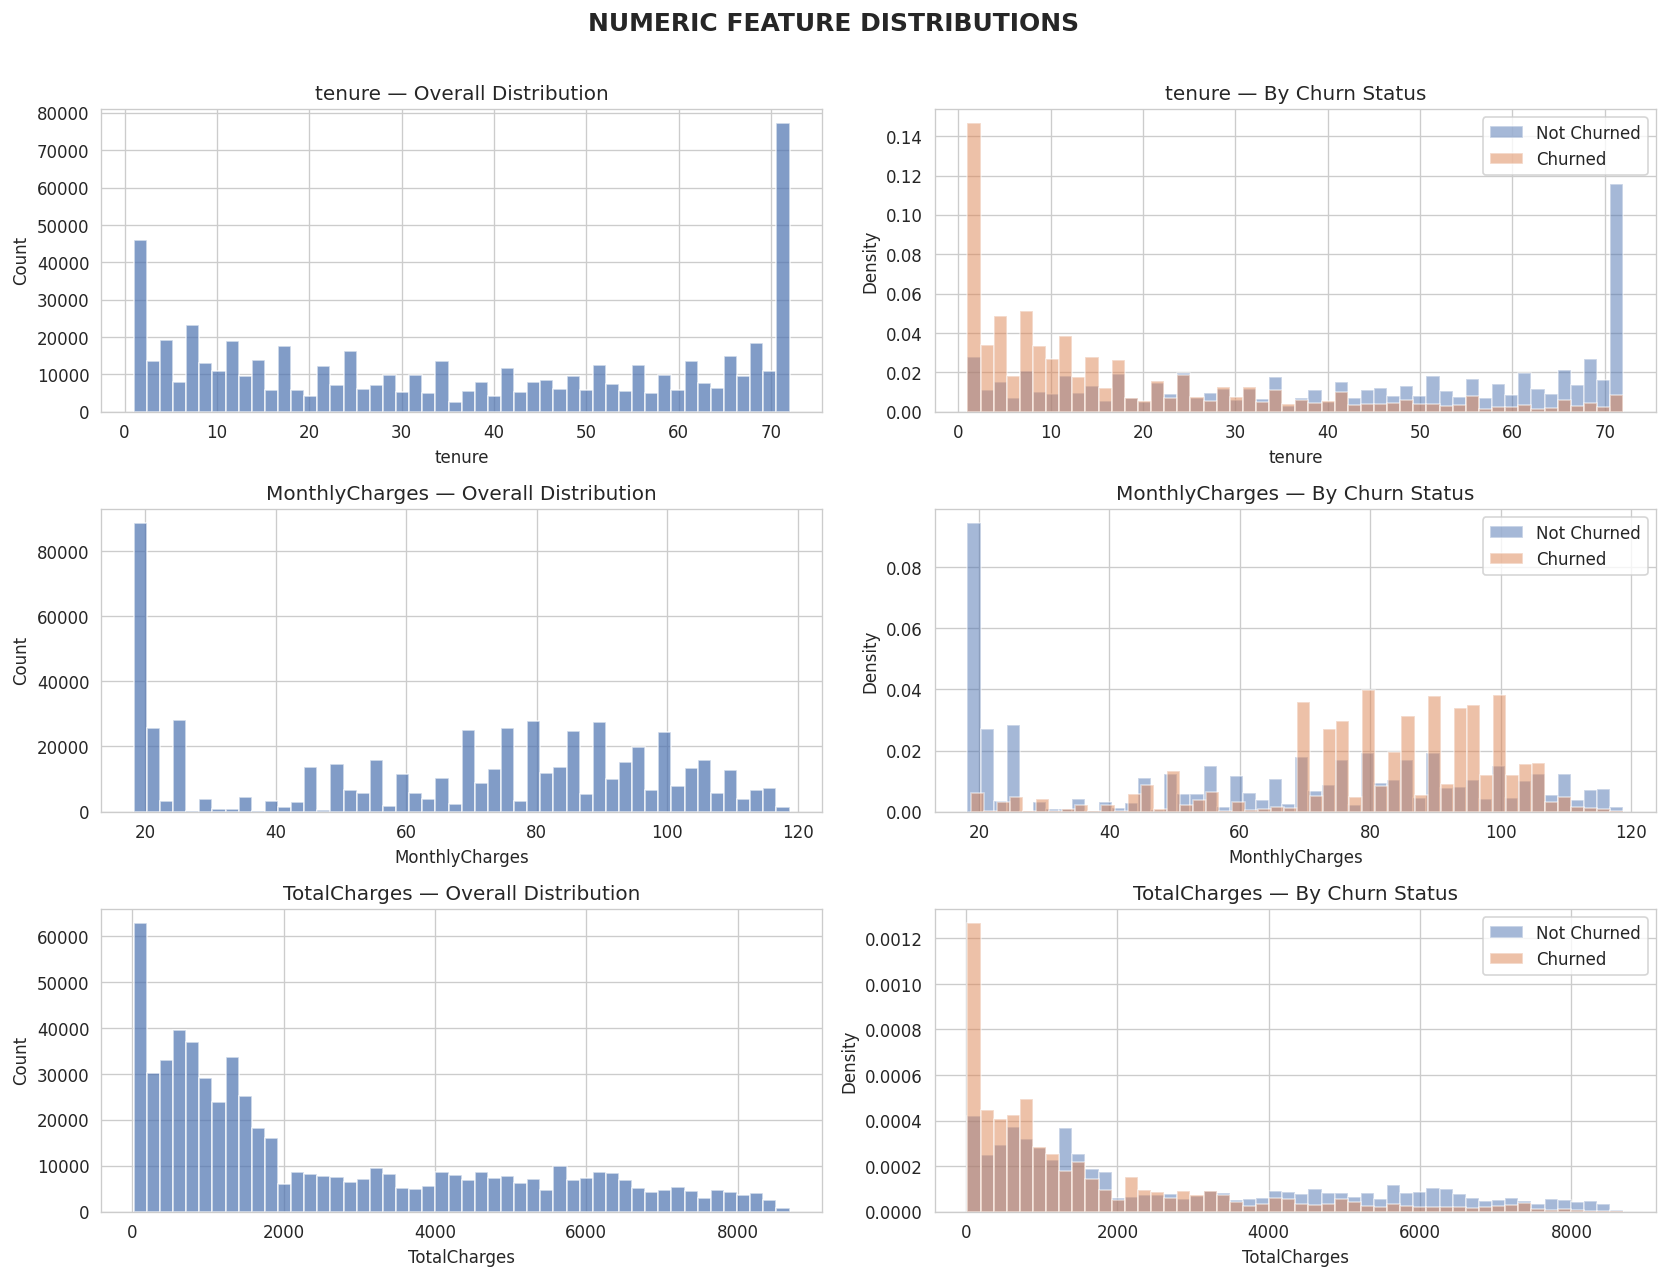

In [62]:
# --- a. Distribution + Churn overlay (KDE plots) ---
fig, axes = plt.subplots(len(num_cols), 2, figsize=(14, len(num_cols) * 3.5))
if len(num_cols) == 1:
    axes = [axes]

for i, col in enumerate(num_cols):
    # Left: overall distribution
    axes[i][0].hist(train[col], bins=50, color="#4C72B0", alpha=0.7, edgecolor="white")
    axes[i][0].set_title(f"{col} — Overall Distribution")
    axes[i][0].set_xlabel(col)
    axes[i][0].set_ylabel("Count")

    # Right: KDE split by Churn
    for churn_val, color, label in [(0, "#4C72B0", "Not Churned"), (1, "#DD8452", "Churned")]:
        subset = train[train["Churn"] == churn_val][col].dropna()
        axes[i][1].hist(subset, bins=50, alpha=0.5, color=color, label=label,
                        density=True, edgecolor="white")
    axes[i][1].set_title(f"{col} — By Churn Status")
    axes[i][1].set_xlabel(col)
    axes[i][1].set_ylabel("Density")
    axes[i][1].legend()

plt.suptitle("NUMERIC FEATURE DISTRIBUTIONS", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

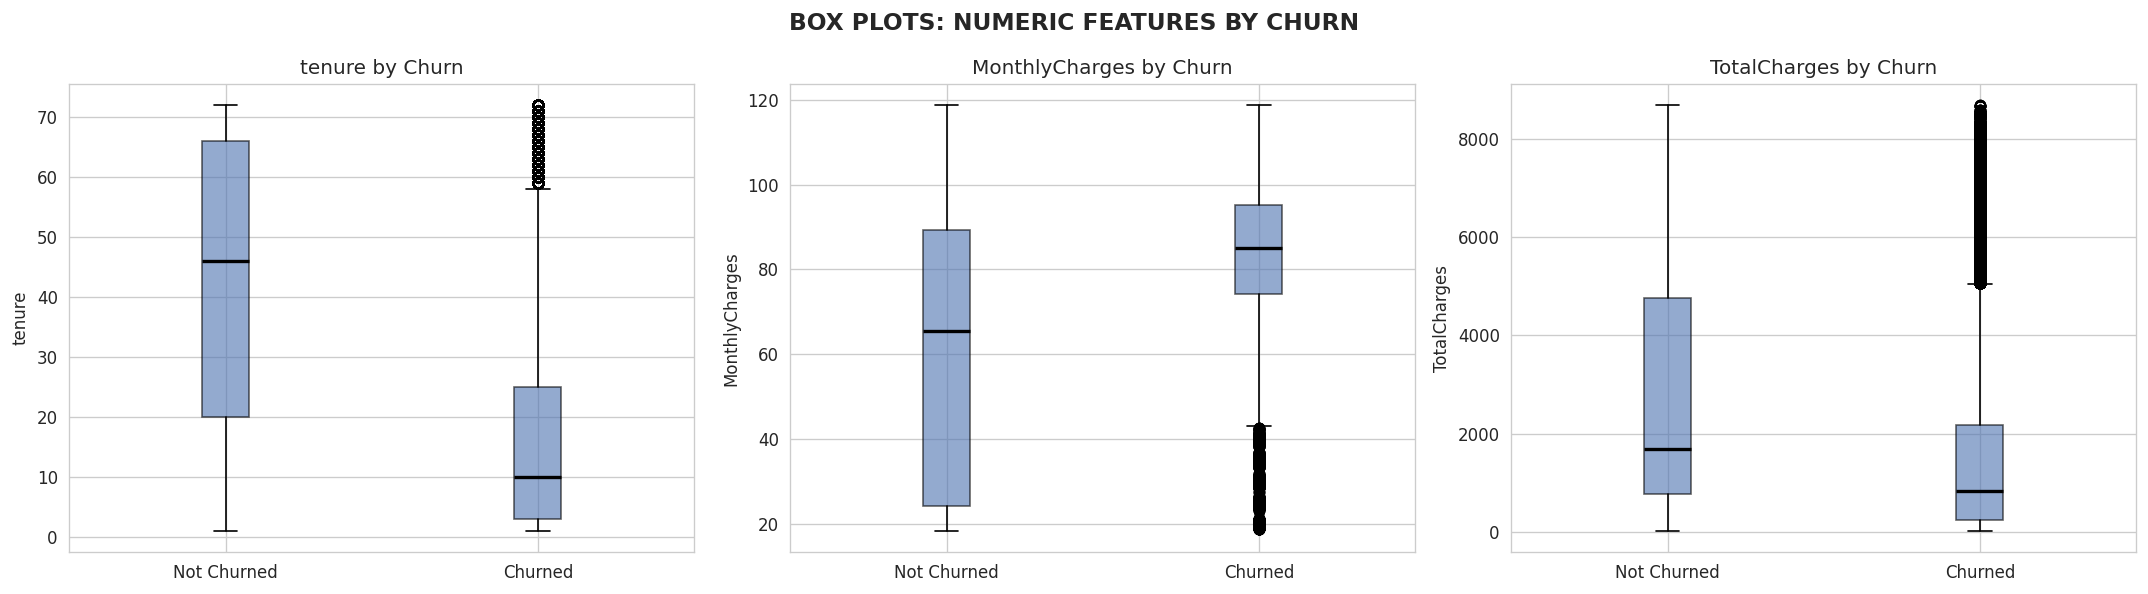

In [63]:
# --- b. Box plots: spread by churn ---
fig, axes = plt.subplots(1, len(num_cols), figsize=(6 * len(num_cols), 5))
if len(num_cols) == 1:
    axes = [axes]

for i, col in enumerate(num_cols):
    data_0 = train[train["Churn"] == 0][col].dropna()
    data_1 = train[train["Churn"] == 1][col].dropna()
    axes[i].boxplot([data_0, data_1], labels=["Not Churned", "Churned"],
                    patch_artist=True,
                    boxprops=dict(facecolor="#4C72B0", alpha=0.6),
                    medianprops=dict(color="black", linewidth=2))
    axes[i].set_title(f"{col} by Churn")
    axes[i].set_ylabel(col)

plt.suptitle("BOX PLOTS: NUMERIC FEATURES BY CHURN", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [64]:
# --- c. Skewness & Kurtosis table ---
skew_kurt = pd.DataFrame({
    "Skewness": train[num_cols].skew().round(3),
    "Kurtosis": train[num_cols].kurtosis().round(3)
})
print("\n📐 Skewness & Kurtosis:")
display(skew_kurt)


📐 Skewness & Kurtosis:


,Skewness,Kurtosis
tenure,0.063,-1.487
MonthlyCharges,-0.289,-1.278
TotalCharges,0.909,-0.446


# STATISTICAL TESTS

In [65]:
print("STATISTICAL SIGNIFICANCE TESTS")

# --- a. Chi-Square test for categorical vs Churn ---
print("\n Chi-Square Test (Categorical ↔ Churn):")
print(f"{'Feature':<25} {'Chi2':>10} {'p-value':>12} {'Significant':>12}")

for col in cat_cols:
    ct = pd.crosstab(train[col], train["Churn"])
    chi2, p, dof, _ = chi2_contingency(ct)
    sig = "✅ YES" if p < 0.05 else "❌ NO"
    print(f"{col:<25} {chi2:>10.2f} {p:>12.4e} {sig:>12}")

STATISTICAL SIGNIFICANCE TESTS

 Chi-Square Test (Categorical ↔ Churn):
Feature                         Chi2      p-value  Significant
gender                         27.51   1.5619e-07        ✅ YES
Partner                     30944.98   0.0000e+00        ✅ YES
Dependents                  34329.59   0.0000e+00        ✅ YES
PhoneService                  721.02  8.0131e-159        ✅ YES
MultipleLines                7888.57   0.0000e+00        ✅ YES
InternetService            107801.94   0.0000e+00        ✅ YES
OnlineSecurity             108175.34   0.0000e+00        ✅ YES
OnlineBackup                79195.70   0.0000e+00        ✅ YES
DeviceProtection            72256.07   0.0000e+00        ✅ YES
TechSupport                103003.06   0.0000e+00        ✅ YES
StreamingTV                 47108.73   0.0000e+00        ✅ YES
StreamingMovies             47173.87   0.0000e+00        ✅ YES
Contract                   132429.25   0.0000e+00        ✅ YES
PaperlessBilling            48298.22   0.0000e

In [66]:
# --- b. Point-biserial correlation for numeric vs Churn ---
print("\n Point-Biserial Correlation (Numeric ↔ Churn):")
print(f"{'Feature':<25} {'Correlation':>12} {'p-value':>12} {'Significant':>12}")
print("-" * 60)
for col in num_cols:
    valid = train[[col, "Churn"]].dropna()
    r, p = pointbiserialr(valid[col], valid["Churn"])
    sig = "✅ YES" if p < 0.05 else "❌ NO"
    print(f"{col:<25} {r:>12.4f} {p:>12.4e} {sig:>12}")


 Point-Biserial Correlation (Numeric ↔ Churn):
Feature                    Correlation      p-value  Significant
------------------------------------------------------------
tenure                         -0.4185   0.0000e+00        ✅ YES
MonthlyCharges                  0.2730   0.0000e+00        ✅ YES
TotalCharges                   -0.2184   0.0000e+00        ✅ YES


# CORRELATION ANALYSIS

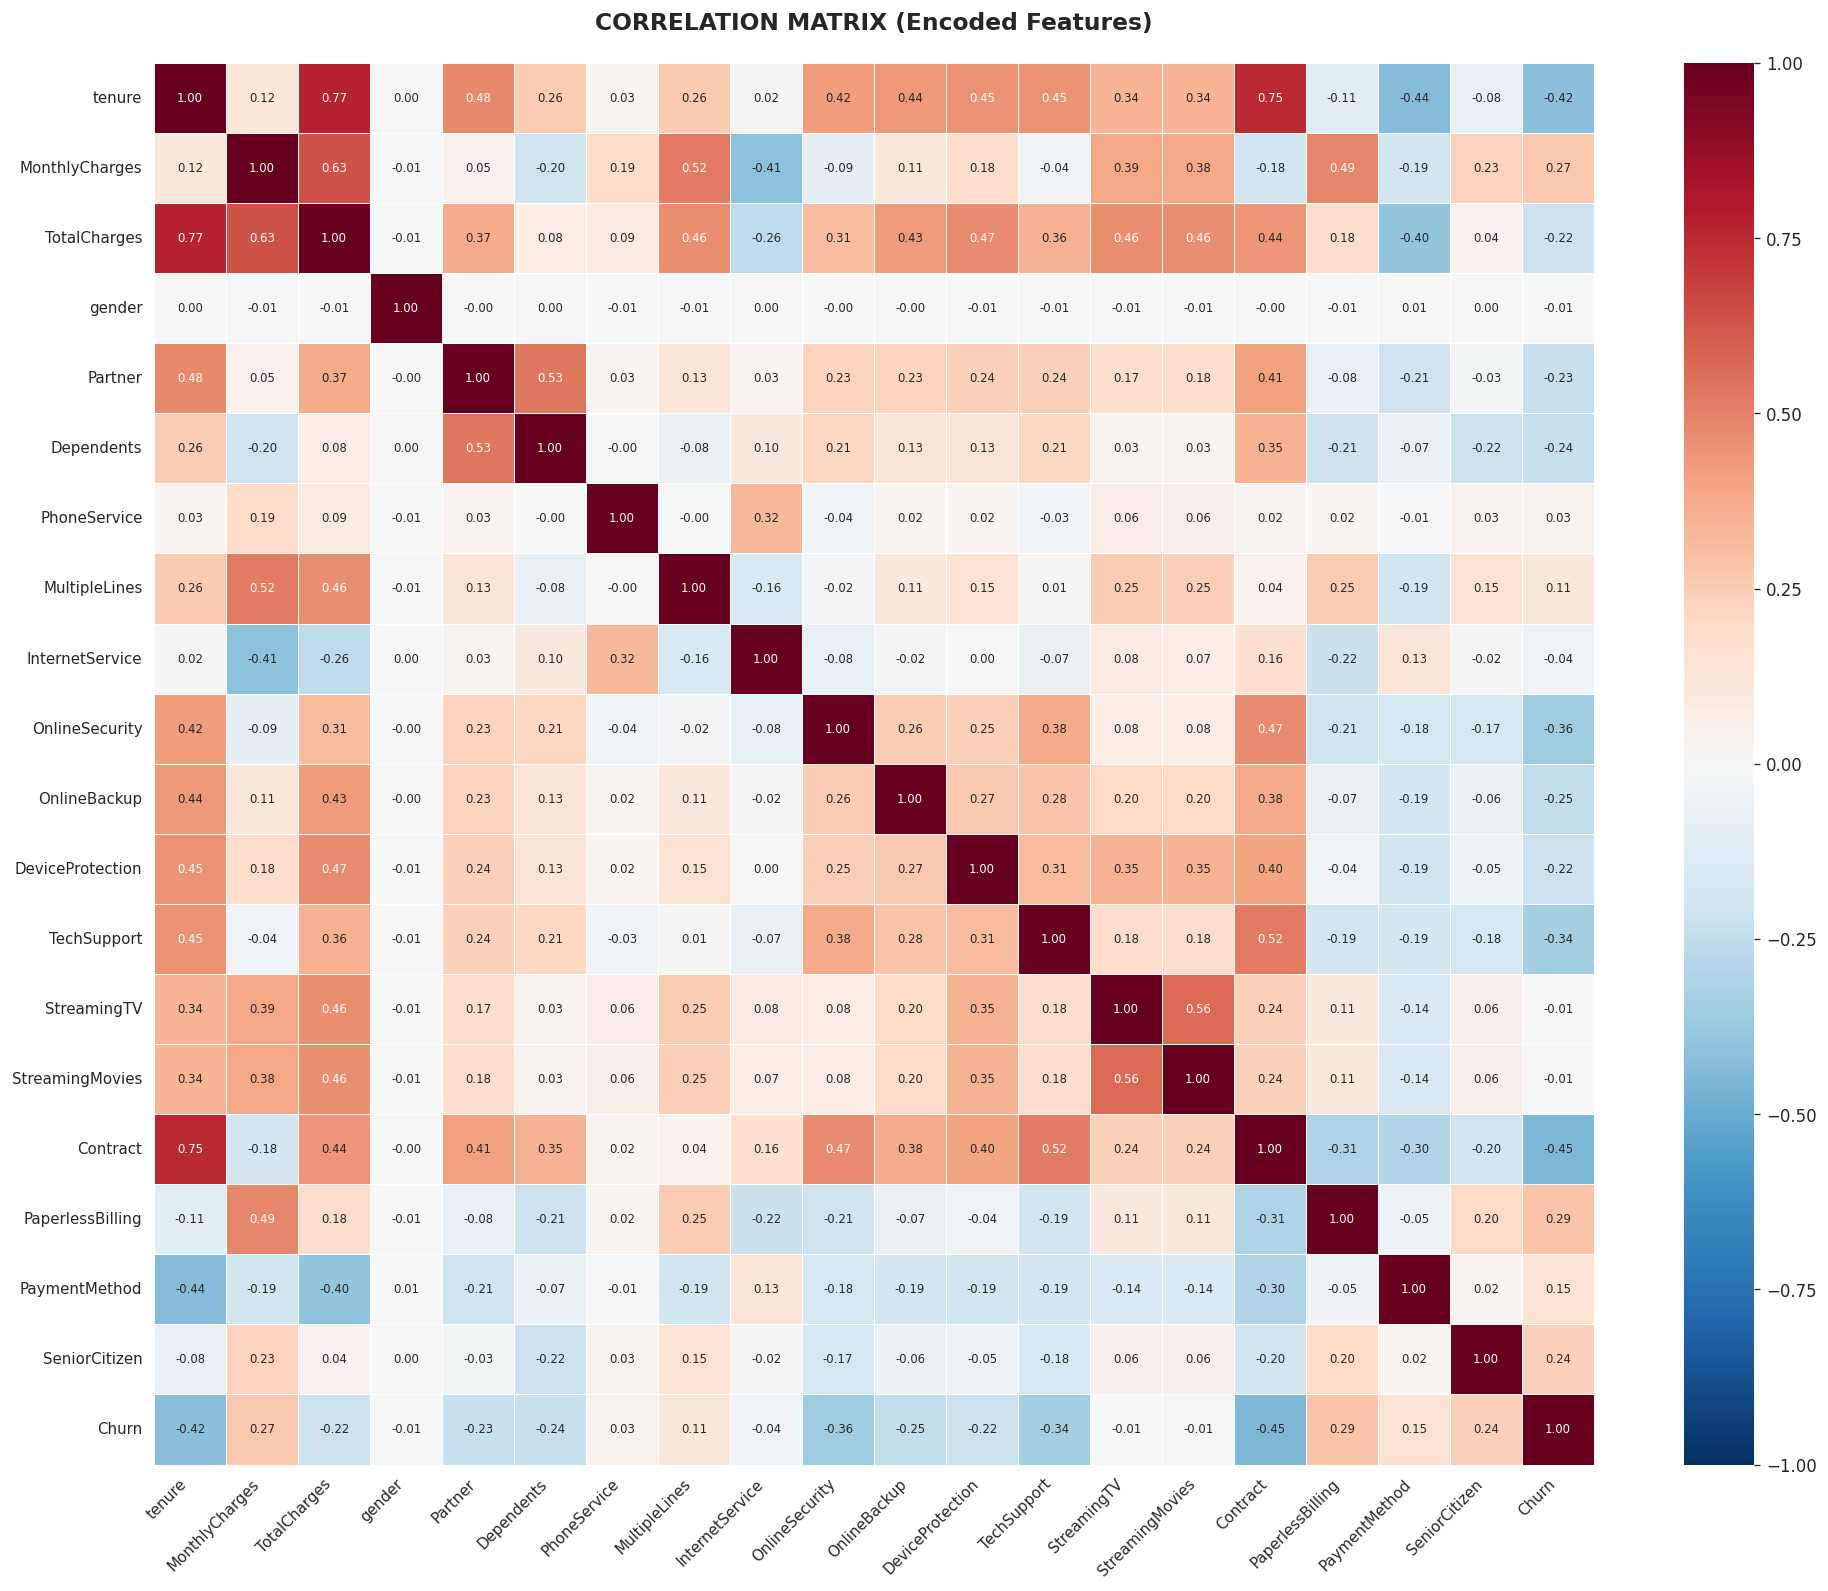

In [67]:
# Encode categoricals for correlation
train_enc = train.copy()
for col in cat_cols:
    train_enc[col] = pd.Categorical(train_enc[col]).codes

corr_cols = num_cols + [c for c in cat_cols] + ["SeniorCitizen", "Churn"]
corr_cols = [c for c in corr_cols if c in train_enc.columns]
corr_matrix = train_enc[corr_cols].corr()

fig, ax = plt.subplots(figsize=(20, 16))  # ← bigger figure

sns.heatmap(corr_matrix, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={"size": 7})

ax.set_title("CORRELATION MATRIX (Encoded Features)", fontsize=14, fontweight="bold", pad=20)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.subplots_adjust(left=0.15, bottom=0.15)  
plt.show()

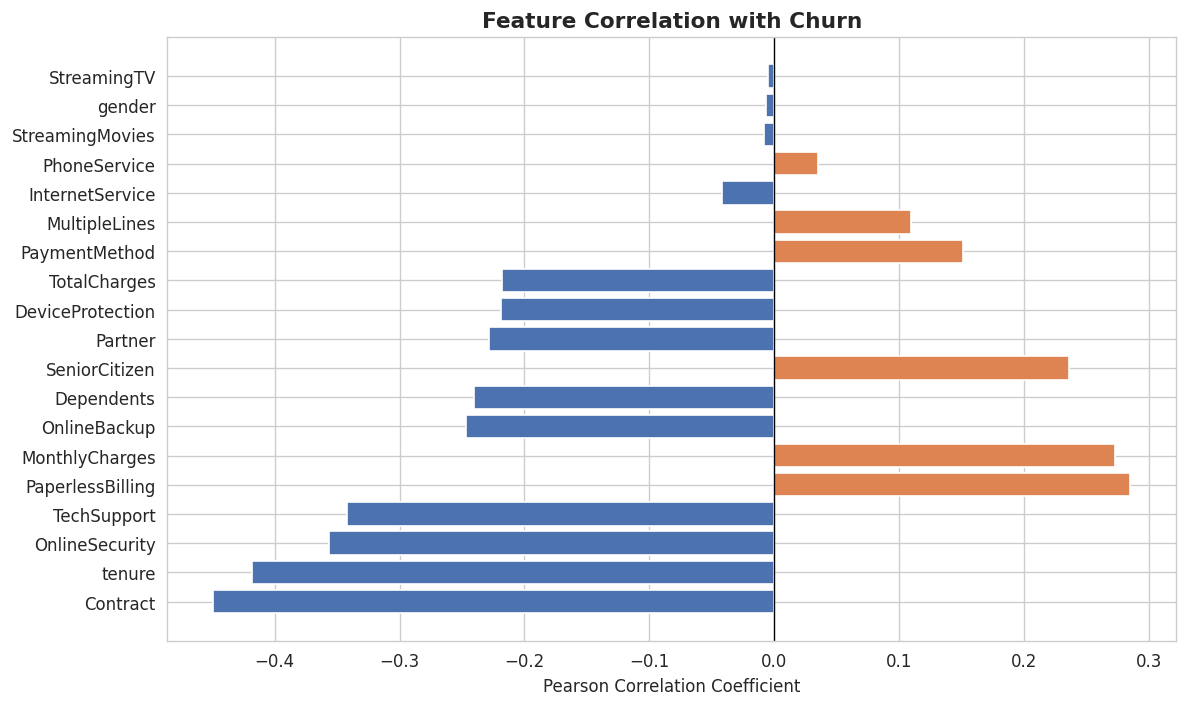

In [68]:
# --- b. Churn correlation bar chart  ---
churn_corr = corr_matrix["Churn"].drop("Churn").sort_values(key=abs, ascending=False)
colors = ["#DD8452" if v > 0 else "#4C72B0" for v in churn_corr.values]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(churn_corr.index, churn_corr.values, color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Feature Correlation with Churn", fontsize=13, fontweight="bold")
ax.set_xlabel("Pearson Correlation Coefficient")
plt.tight_layout()
plt.show()

# MULTIVARIATE ANALYSIS

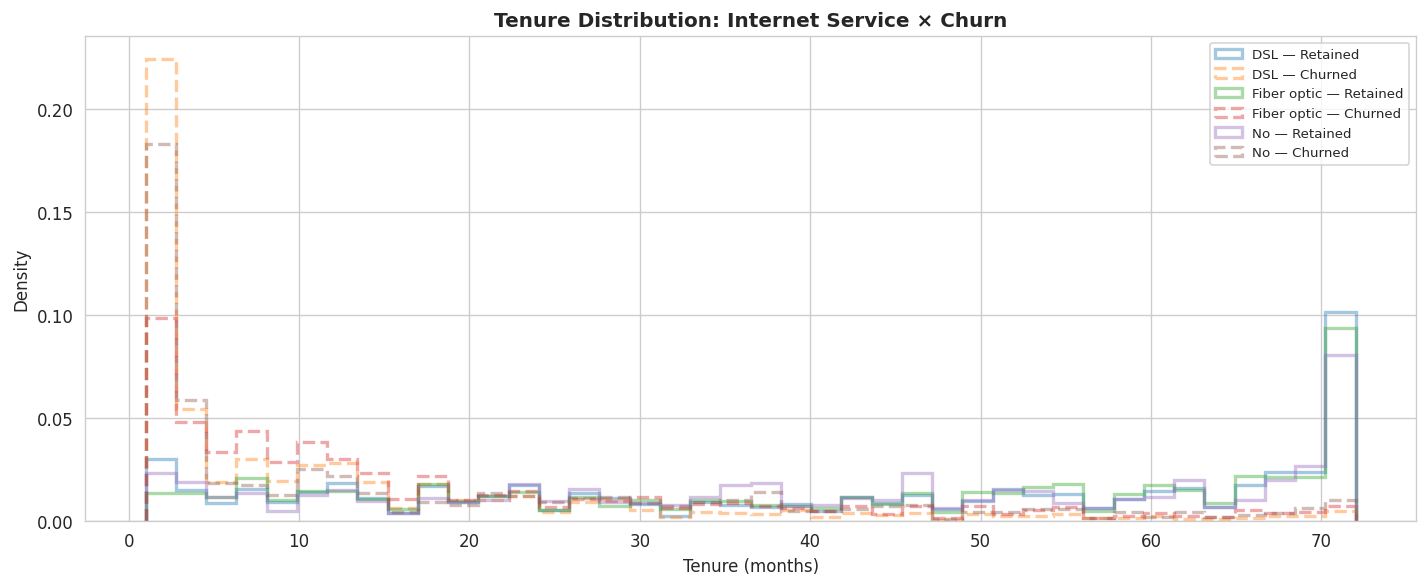

In [69]:
# --- 8a. Tenure by Internet Service type and Churn ---
if "tenure" in train.columns and "InternetService" in train.columns:
    fig, ax = plt.subplots(figsize=(12, 5))
    for service in train["InternetService"].unique():
        for churn_val, ls in [(0, "-"), (1, "--")]:
            subset = train[(train["InternetService"] == service) & (train["Churn"] == churn_val)]
            label = f"{service} — {'Churned' if churn_val else 'Retained'}"
            ax.hist(subset["tenure"], bins=40, alpha=0.4, density=True, label=label, histtype="step", linewidth=2, linestyle=ls)
    ax.set_title("Tenure Distribution: Internet Service × Churn", fontweight="bold")
    ax.set_xlabel("Tenure (months)")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

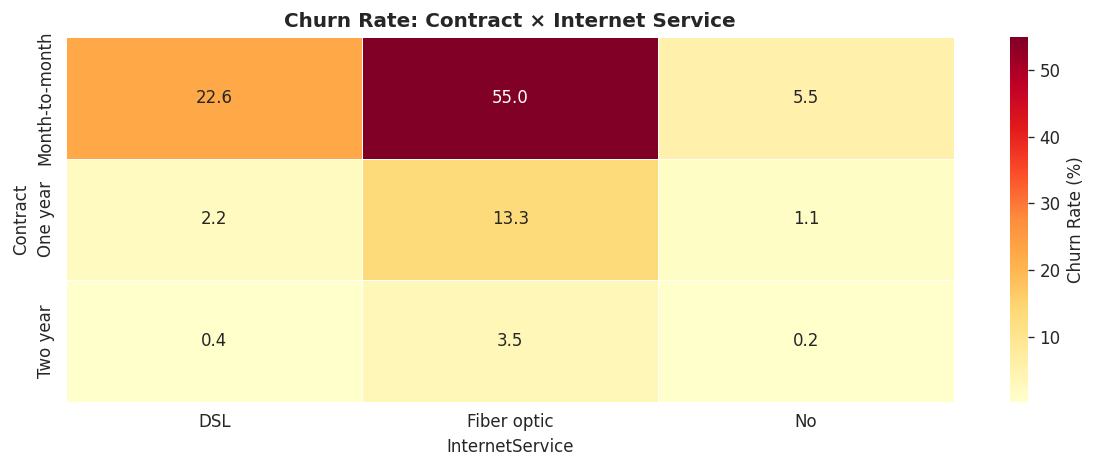

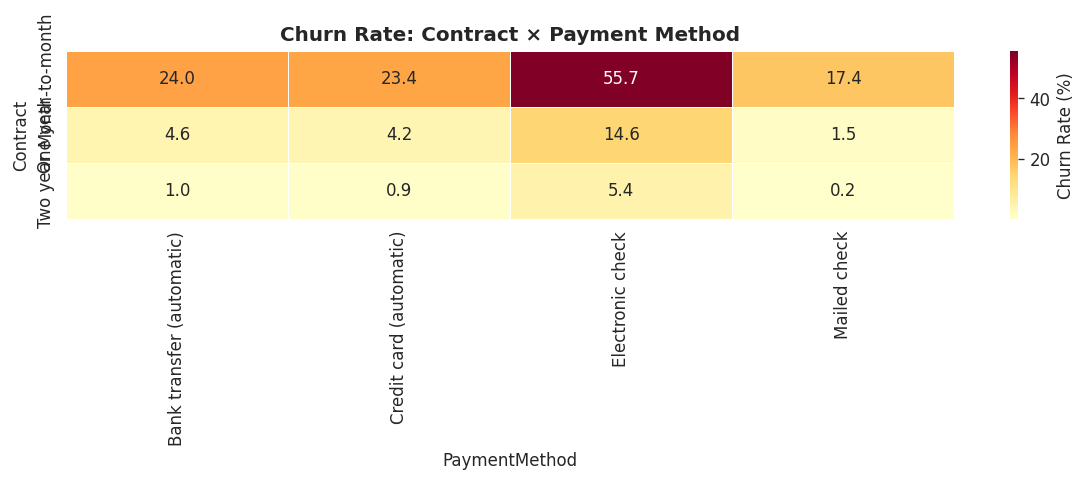

In [70]:
# --- b. Heatmap: Churn rate for two categorical features ---
def churn_heatmap(col1, col2, title=""):
    pivot = train.pivot_table(values="Churn", index=col1, columns=col2, aggfunc="mean") * 100
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=0.5,
                cbar_kws={"label": "Churn Rate (%)"}, ax=ax)
    ax.set_title(title or f"Churn Rate: {col1} × {col2}", fontweight="bold")
    plt.tight_layout()
    plt.show()

if "Contract" in train.columns and "InternetService" in train.columns:
    churn_heatmap("Contract", "InternetService", "Churn Rate: Contract × Internet Service")

if "PaymentMethod" in train.columns and "Contract" in train.columns:
    churn_heatmap("Contract", "PaymentMethod", "Churn Rate: Contract × Payment Method")


# FEATURE ENGINEERING

In [71]:
print("FEATURE ENGINEERING")

# a. Tenure groups
train["tenure_group"] = pd.cut(
    train["tenure"],
    bins=[0, 12, 36, 60, 72],
    labels=["New", "Mid", "Established", "Loyal"]
)
print("\nTenure Group Churn %:")
print((train.groupby("tenure_group")["Churn"].mean() * 100).round(2))

FEATURE ENGINEERING

Tenure Group Churn %:
tenure_group
New            49.39
Mid            25.15
Established    10.94
Loyal           3.66
Name: Churn, dtype: float64


In [72]:
# b. Month-to-month flag
train["is_month_to_month"] = (train["Contract"] == "Month-to-month").astype(int)
print("\nis_month_to_month Churn %:")
print((train.groupby("is_month_to_month")["Churn"].mean() * 100).round(2))


is_month_to_month Churn %:
is_month_to_month
0     2.75
1    42.05
Name: Churn, dtype: float64


In [73]:
# c. Fiber optic flag
train["is_fiber"] = (train["InternetService"] == "Fiber optic").astype(int)
print("\nis_fiber Churn %:")
print((train.groupby("is_fiber")["Churn"].mean() * 100).round(2))


is_fiber Churn %:
is_fiber
0     6.43
1    41.54
Name: Churn, dtype: float64


In [74]:
# d. Protection services count
protection_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport"]
train["protection_count"] = sum((train[c] == "Yes").astype(int) for c in protection_cols)
print("\nprotection_count Churn %:")
print((train.groupby("protection_count")["Churn"].mean() * 100).round(2))


protection_count Churn %:
protection_count
0    24.71
1    39.41
2    20.32
3     6.29
4     1.93
Name: Churn, dtype: float64


In [75]:
# e. Streaming flag
train["has_streaming"] = (
    (train["StreamingTV"] == "Yes") | (train["StreamingMovies"] == "Yes")
).astype(int)
print("\nhas_streaming Churn %:")
print((train.groupby("has_streaming")["Churn"].mean() * 100).round(2))


has_streaming Churn %:
has_streaming
0    16.20
1    29.14
Name: Churn, dtype: float64


In [76]:
# f. High-risk combo (Month-to-month + Fiber + Tenure ≤12)
train["high_risk"] = (
    (train["is_month_to_month"] == 1) &
    (train["is_fiber"] == 1) &
    (train["tenure"] <= 12)
).astype(int)
print("\nhigh_risk Churn %:")
print((train.groupby("high_risk")["Churn"].mean() * 100).round(2))


high_risk Churn %:
high_risk
0    14.28
1    70.81
Name: Churn, dtype: float64


In [77]:
# g. Monthly charge normalized by tenure
train["monthly_charge_per_tenure"] = train["MonthlyCharges"] / (train["tenure"] + 1)
print("\nmonthly_charge_per_tenure stats:")
print(train["monthly_charge_per_tenure"].describe().round(2))


monthly_charge_per_tenure stats:
count    594194.00
mean          4.88
std           7.85
min           0.25
25%           1.10
50%           1.76
75%           4.76
max          53.45
Name: monthly_charge_per_tenure, dtype: float64


In [78]:
# h. Digital risk (Paperless + Electronic check)
train["digital_risk"] = (
    (train["PaperlessBilling"] == "Yes") &
    (train["PaymentMethod"] == "Electronic check")
).astype(int)
print("\ndigital_risk Churn %:")
print((train.groupby("digital_risk")["Churn"].mean() * 100).round(2))


digital_risk Churn %:
digital_risk
0     9.49
1    52.04
Name: Churn, dtype: float64


In [79]:
# i. Senior + Fiber interaction
train["senior_fiber"] = (
    (train["SeniorCitizen"] == 1) &
    (train["is_fiber"] == 1)
).astype(int)
print("\nsenior_fiber Churn %:")
print((train.groupby("senior_fiber")["Churn"].mean() * 100).round(2))


senior_fiber Churn %:
senior_fiber
0    19.02
1    54.89
Name: Churn, dtype: float64


In [80]:
# Summary
new_features = [
    "tenure_group", "is_month_to_month", "is_fiber", "protection_count",
    "has_streaming", "high_risk", "monthly_charge_per_tenure",
    "digital_risk", "senior_fiber"
]

print(f"\nTotal new features created: {len(new_features)}")
print("\nFeature correlations with Churn:")
for f in new_features:
    if train[f].dtype.name != "category":
        print(f"{f:<30} r = {train[f].corr(train['Churn']):+.4f}")


Total new features created: 9

Feature correlations with Churn:
is_month_to_month              r = +0.4705
is_fiber                       r = +0.4188
protection_count               r = -0.1915
has_streaming                  r = +0.1548
high_risk                      r = +0.4774
monthly_charge_per_tenure      r = +0.4764
digital_risk                   r = +0.4696
senior_fiber                   r = +0.2547


# TRAIN vs TEST DISTRIBUTION CHECK

In [81]:
print("TRAIN vs TEST DISTRIBUTION CHECK")
print(f"Train: {train.shape[0]:,} rows | Test: {test.shape[0]:,} rows")

from scipy.stats import ks_2samp

TRAIN vs TEST DISTRIBUTION CHECK
Train: 594,194 rows | Test: 254,655 rows



Numeric Features — KS Test
Feature                KS Stat        p-value    Status
-------------------------------------------------------
tenure                  0.0171     1.5501e-45     SHIFT
MonthlyCharges          0.0065     4.9451e-07     SHIFT
TotalCharges            0.0177     5.3836e-49     SHIFT


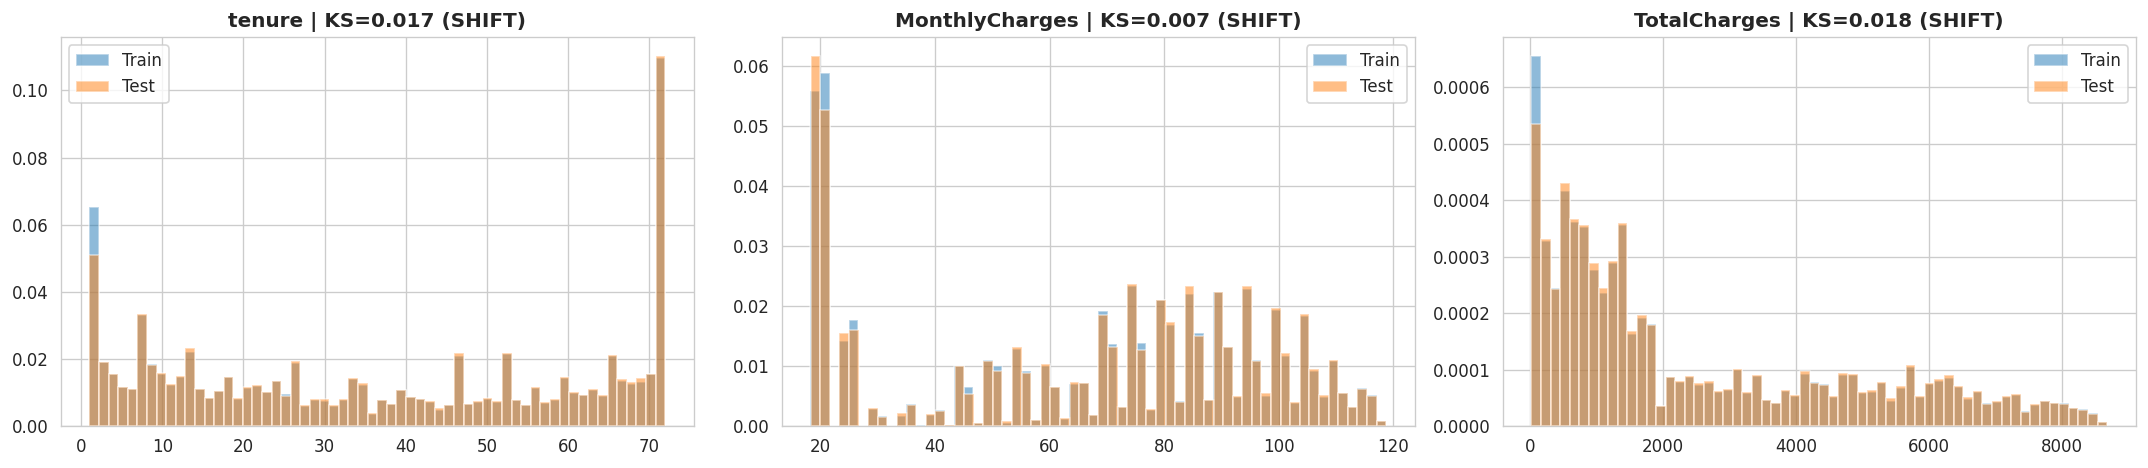

In [82]:
# a. Numeric distribution check (KS Test)
num_check = ["tenure", "MonthlyCharges", "TotalCharges"]

print("\nNumeric Features — KS Test")
print(f"{'Feature':<20}{'KS Stat':>10}{'p-value':>15}{'Status':>10}")
print("-" * 55)

ks_results = {}
for col in num_check:
    tr, te = train[col].dropna(), test[col].dropna()
    ks_stat, ks_p = ks_2samp(tr, te)
    status = "SHIFT" if ks_p < 0.05 else "OK"
    ks_results[col] = (ks_stat, ks_p)
    print(f"{col:<20}{ks_stat:>10.4f}{ks_p:>15.4e}{status:>10}")

# 10b. Numeric distribution plots
fig, axes = plt.subplots(1, len(num_check), figsize=(18, 4))
for i, col in enumerate(num_check):
    axes[i].hist(train[col], bins=60, alpha=0.5, density=True, label="Train", edgecolor="white")
    axes[i].hist(test[col],  bins=60, alpha=0.5, density=True, label="Test",  edgecolor="white")
    ks_stat, ks_p = ks_results[col]
    status = "SHIFT" if ks_p < 0.05 else "OK"
    axes[i].set_title(f"{col} | KS={ks_stat:.3f} ({status})", fontweight="bold")
    axes[i].legend()
plt.tight_layout()
plt.show()


Categorical Features — Max % Difference
Contract             0.75%
InternetService      0.00%
PaymentMethod        0.47%
PaperlessBilling     0.02%


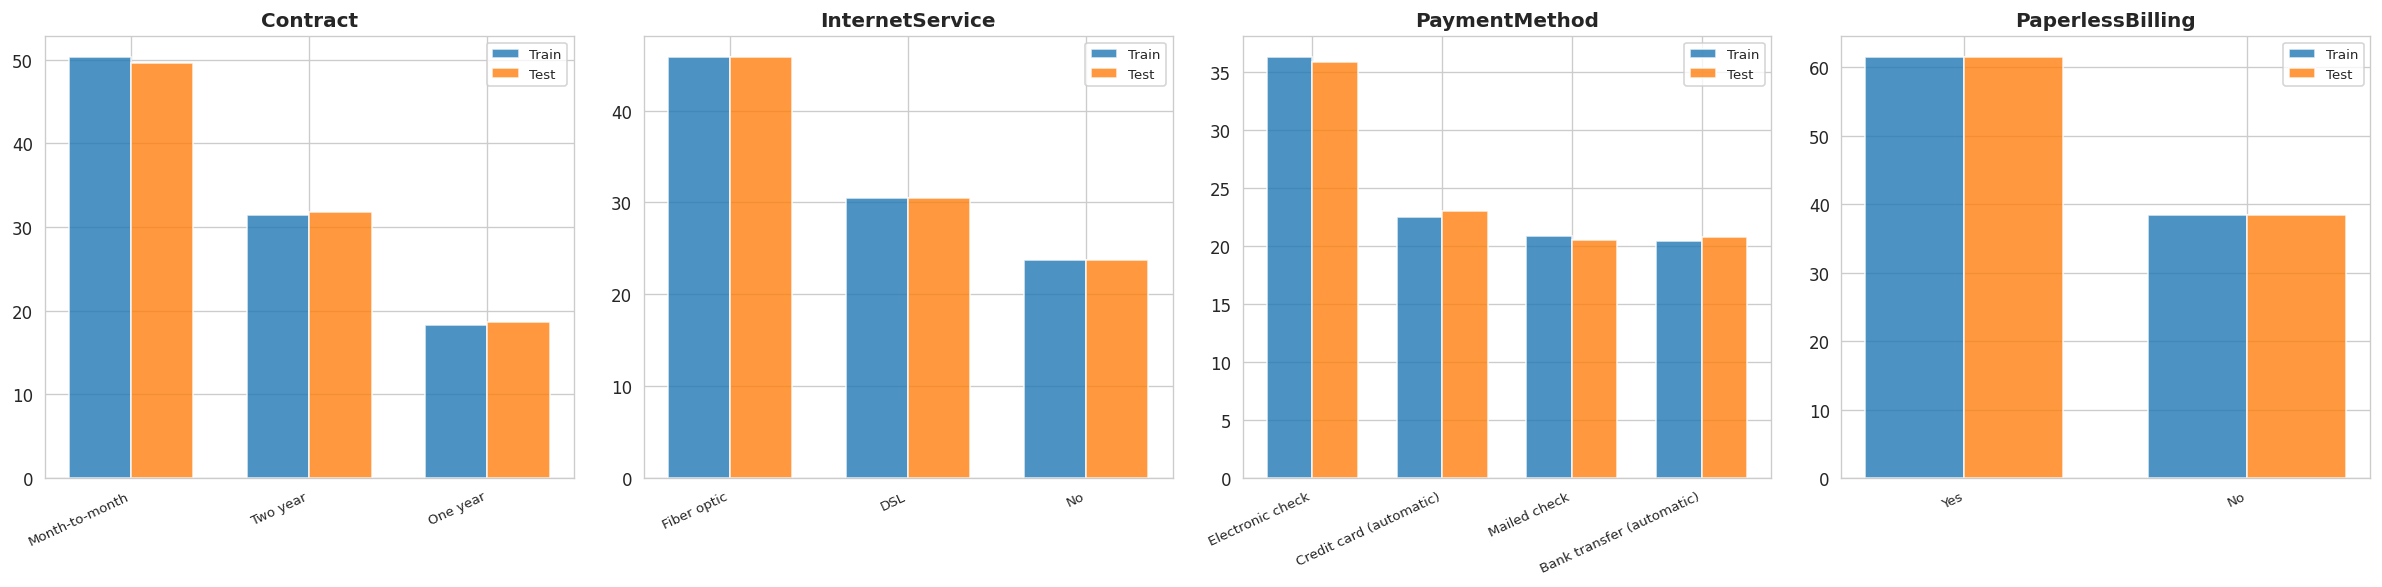

In [83]:
# c. Categorical proportion comparison
cat_check = ["Contract", "InternetService", "PaymentMethod", "PaperlessBilling"]

print("\nCategorical Features — Max % Difference")
fig, axes = plt.subplots(1, len(cat_check), figsize=(20, 5))

for i, col in enumerate(cat_check):
    tr_pct = train[col].value_counts(normalize=True) * 100
    te_pct = test[col].value_counts(normalize=True) * 100
    cats = tr_pct.index
    x = range(len(cats))
    width = 0.35

    axes[i].bar([xi - width/2 for xi in x], tr_pct[cats], width, label="Train", alpha=0.8)
    axes[i].bar([xi + width/2 for xi in x], te_pct[cats], width, label="Test",  alpha=0.8)

    axes[i].set_xticks(list(x))
    axes[i].set_xticklabels(cats, rotation=25, ha="right", fontsize=8)
    axes[i].set_title(col, fontweight="bold")
    axes[i].legend(fontsize=8)

    max_diff = max(abs(tr_pct.get(c, 0) - te_pct.get(c, 0)) for c in cats)
    print(f"{col:<20} {max_diff:.2f}%")

plt.tight_layout()
plt.show()

#  EDA SUMMARY

In [84]:
print("EDA SUMMARY")

# a. Categorical summary (Chi2)
cat_summary = []
for col in cat_cols:
    ct = pd.crosstab(train[col], train["Churn"])
    chi2, p, _, _ = chi2_contingency(ct)
    churn_rate = train.groupby(col)["Churn"].mean() * 100

    cat_summary.append({
        "Feature": col,
        "Categories": train[col].nunique(),
        "Top Churn": f"{churn_rate.idxmax()} ({churn_rate.max():.1f}%)",
        "Low Churn": f"{churn_rate.idxmin()} ({churn_rate.min():.1f}%)",
        "Chi2": round(chi2, 0),
        "Significant": "Yes" if p < 0.05 else "No"
    })

cat_summary_df = pd.DataFrame(cat_summary).sort_values("Chi2", ascending=False)
display(cat_summary_df)

EDA SUMMARY


,Feature,Categories,Top Churn,Low Churn,Chi2,Significant
14,PaymentMethod,4,Electronic check (48.9%),Credit card (automatic) (6.9%),134818.0,Yes
12,Contract,3,Month-to-month (42.1%),Two year (1.0%),132429.0,Yes
6,OnlineSecurity,3,No (40.6%),No internet service (1.4%),108175.0,Yes
5,InternetService,3,Fiber optic (41.5%),No (1.4%),107802.0,Yes
9,TechSupport,3,No (40.2%),No internet service (1.4%),103003.0,Yes
7,OnlineBackup,3,No (39.1%),No internet service (1.4%),79196.0,Yes
8,DeviceProtection,3,No (38.1%),No internet service (1.4%),72256.0,Yes
13,PaperlessBilling,2,Yes (31.9%),No (7.5%),48298.0,Yes
11,StreamingMovies,3,No (29.9%),No internet service (1.4%),47174.0,Yes
10,StreamingTV,3,No (29.7%),No internet service (1.4%),47109.0,Yes


In [85]:
# b. Numeric summary (Point-Biserial Correlation)
num_summary = []
for col in num_cols:
    valid = train[[col, "Churn"]].dropna()
    r, p = pointbiserialr(valid[col], valid["Churn"])

    num_summary.append({
        "Feature": col,
        "Corr w/ Churn": round(r, 4),
        "Mean (Churn=1)": round(train[train["Churn"] == 1][col].mean(), 2),
        "Mean (Churn=0)": round(train[train["Churn"] == 0][col].mean(), 2),
        "Skewness": round(train[col].skew(), 3),
        "Significant": "Yes" if p < 0.05 else "No"
    })

num_summary_df = pd.DataFrame(num_summary).sort_values(
    "Corr w/ Churn", key=abs, ascending=False
)
display(num_summary_df)

,Feature,Corr w/ Churn,Mean (Churn=1),Mean (Churn=0),Skewness,Significant
0,tenure,-0.4185,17.13,42.23,0.063,Yes
1,MonthlyCharges,0.2730,81.60,61.29,-0.289,Yes
2,TotalCharges,-0.2184,1540.98,2771.50,0.909,Yes


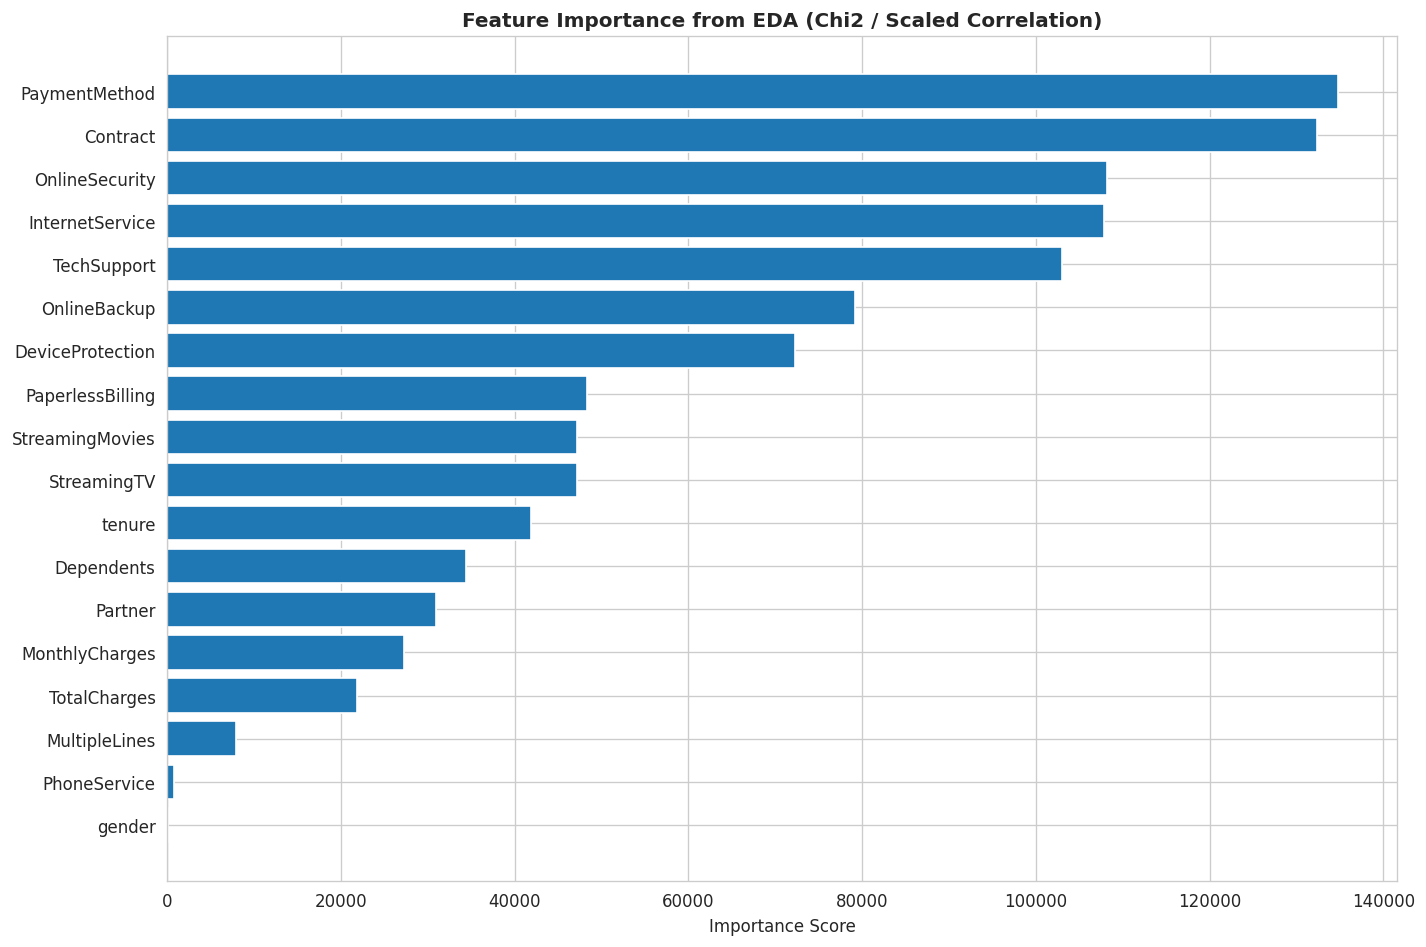


EDA Complete → Feature priorities established.


In [86]:
# c. Feature ranking chart
all_features = cat_summary_df[["Feature", "Chi2"]].copy()
all_features.columns = ["Feature", "Score"]

for _, row in num_summary_df.iterrows():
    all_features = pd.concat([all_features, pd.DataFrame([{
        "Feature": row["Feature"],
        "Score": abs(row["Corr w/ Churn"]) * 100000
    }])], ignore_index=True)

all_features = all_features.sort_values("Score")

plt.figure(figsize=(12, 8))
plt.barh(all_features["Feature"], all_features["Score"])
plt.title("Feature Importance from EDA (Chi2 / Scaled Correlation)", fontweight="bold")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

print("\nEDA Complete → Feature priorities established.")